In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
print("Dataset shape:",df.shape)

Dataset shape: (10000, 14)


In [ ]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Check machine failure distribution

print(df['Machine failure'].value_counts())

print("\nPercentage:")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


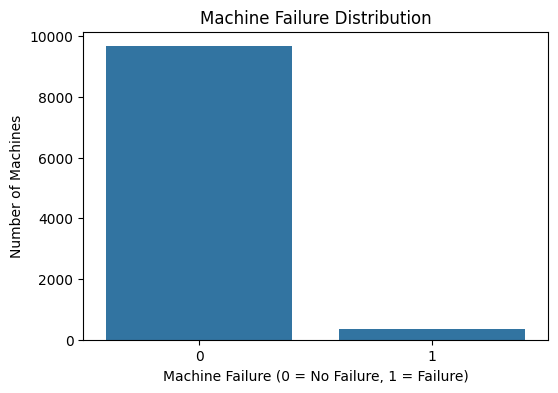

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count machine failures
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
plt.ylabel('Number of Machines')
plt.show()

In [ ]:
failure_counts = df['Machine failure'].value_counts()

print("No Failure (0):", failure_counts[0])
print("Failure (1):", failure_counts[1])

No Failure (0): 9661
Failure (1): 339


In [ ]:
# Select important numerical features
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Compare average values for failed and non-failed machines
df.groupby('Machine failure')[features].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


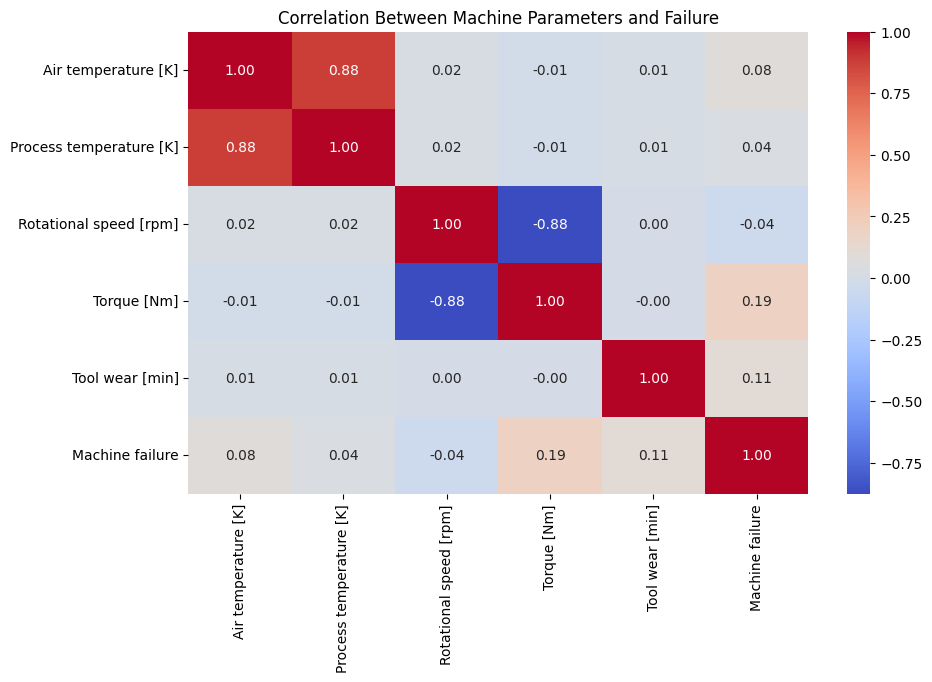

In [ ]:
plt.figure(figsize=(10, 6))

correlation = df[features + ['Machine failure']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Machine Parameters and Failure')
plt.show()

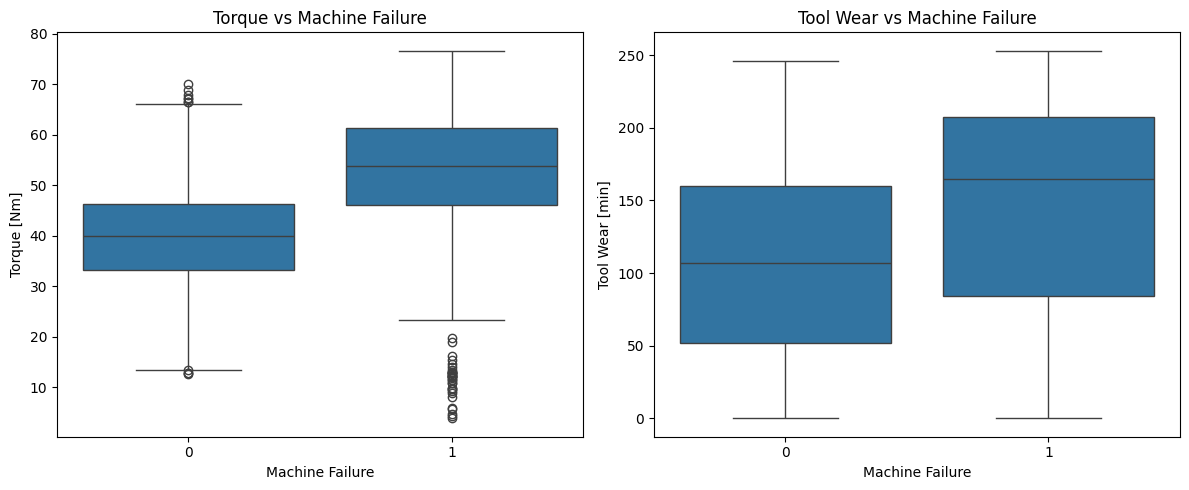

In [ ]:
# Compare machine parameters based on failure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df,
    ax=axes[0]
)
axes[0].set_title('Torque vs Machine Failure')
axes[0].set_xlabel('Machine Failure')
axes[0].set_ylabel('Torque [Nm]')

sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df,
    ax=axes[1]
)
axes[1].set_title('Tool Wear vs Machine Failure')
axes[1].set_xlabel('Machine Failure')
axes[1].set_ylabel('Tool Wear [min]')

plt.tight_layout()
plt.show()

In [ ]:
# Select input features
X = df[
    [
        'Type',
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
]

# Select target
y = df['Machine failure']

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (10000, 6)
Target shape: (10000,)


In [ ]:
# Convert categorical Type column into numerical columns
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

print(X.head())
print("\nNew shape:", X.shape)

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_L  Type_M  
0         42.8                0   False    True  
1         46.3                3    True   False  
2         49.4                5    True   False  
3         39.5                7    True   False  
4         40.0                9    True   False  

New shape: (10000, 7)


In [ ]:
print("Features used for prediction:")
print(X.columns.tolist())

Features used for prediction:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8000, 7)
Testing data shape: (2000, 7)


In [ ]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.24768129, -0.13929361, -1.07396322, ...,  0.71241009,
         0.81013252, -0.65095382],
       [ 1.85031019,  1.61824785, -0.14564092, ...,  0.42942694,
         0.81013252, -0.65095382],
       [ 1.24932436,  0.94227037,  0.10854256, ...,  1.59280213,
         0.81013252, -0.65095382],
       ...,
       [-0.95429039, -1.42365083, -0.51586469, ...,  0.20932893,
        -1.23436595,  1.53620728],
       [ 1.1992422 ,  1.28025911, -0.64848216, ...,  1.35698283,
        -1.23436595,  1.53620728],
       [-1.0544547 , -0.6800756 ,  2.37961675, ..., -1.11125913,
        -1.23436595,  1.53620728]])

train logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


make predictions

In [ ]:
# Predict the test data
y_pred_lr = logistic_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_lr[:20])

First 20 predictions:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


evaluate the model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1 Score : 0.17721518987341772


knn model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
# Predict using KNN
y_pred_knn = knn_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_knn[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

KNN Results
-----------
Accuracy : 0.974
Precision: 0.8333333333333334
Recall   : 0.29411764705882354
F1 Score : 0.43478260869565216


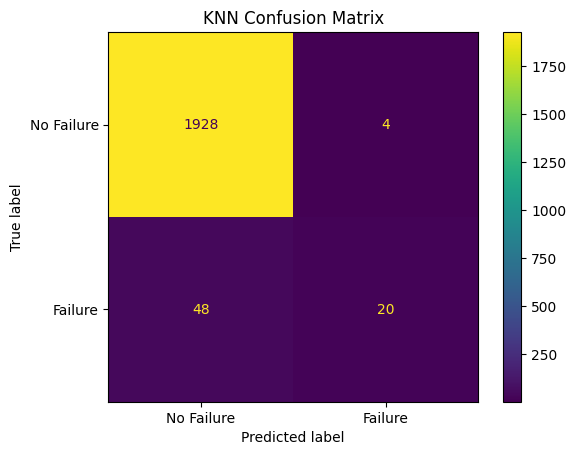

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['No Failure', 'Failure']
)

disp.plot()
plt.title('KNN Confusion Matrix')
plt.show()

decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Predict using Decision Tree
y_pred_dt = decision_tree_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_dt[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
---------------------
Accuracy : 0.973
Precision: 0.7692307692307693
Recall   : 0.29411764705882354
F1 Score : 0.425531914893617


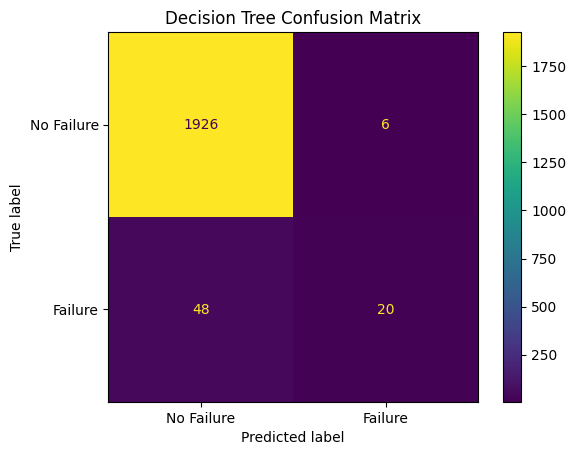

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['No Failure', 'Failure']
)

disp.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

comparison of 3 models

In [ ]:
# Create a comparison table

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt
    ],
    'Precision': [
        precision_lr,
        precision_knn,
        precision_dt
    ],
    'Recall': [
        recall_lr,
        recall_knn,
        recall_dt
    ],
    'F1 Score': [
        f1_lr,
        f1_knn,
        f1_dt
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215
1,KNN,0.9740,0.833333,0.294118,0.434783
2,Decision Tree,0.9730,0.769231,0.294118,0.425532


In [ ]:
# Round the values for easier reading

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772
1,KNN,0.9740,0.8333,0.2941,0.4348
2,Decision Tree,0.9730,0.7692,0.2941,0.4255


In [ ]:
from sklearn.metrics import classification_report

print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))

print("===== KNN =====")
print(classification_report(y_test, y_pred_knn))

print("===== Decision Tree =====")
print(classification_report(y_test, y_pred_dt))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000

===== KNN =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.77      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.87      0.65      0.71      2000


roc curve

In [ ]:
# Get probability predictions

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_knn = roc_auc_score(y_test, y_prob_knn)
roc_dt = roc_auc_score(y_test, y_prob_dt)

print("ROC-AUC Scores")
print("----------------")
print("Logistic Regression:", round(roc_lr, 4))
print("KNN:", round(roc_knn, 4))
print("Decision Tree:", round(roc_dt, 4))

ROC-AUC Scores
----------------
Logistic Regression: 0.8995
KNN: 0.8292
Decision Tree: 0.9147


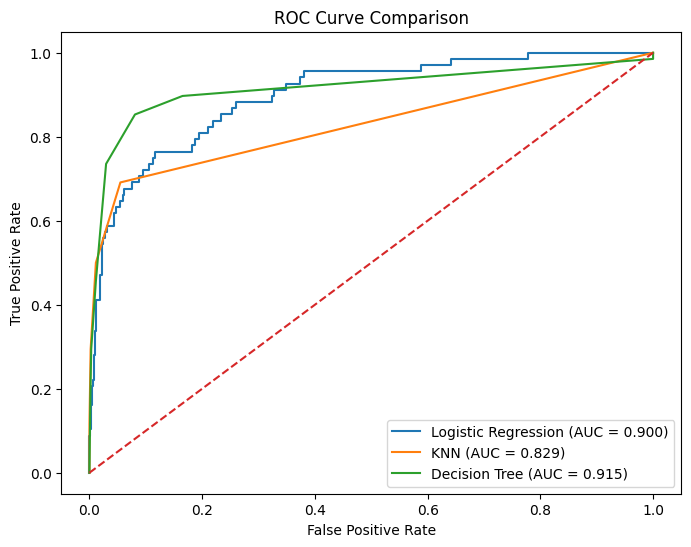

In [ ]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_lr:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_knn:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_dt:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with balanced class weights
logistic_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logistic_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_balanced = logistic_balanced.predict(X_test_scaled)

print("Balanced Logistic Regression")
print(classification_report(y_test, y_pred_lr_balanced))

Balanced Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree with balanced class weights
decision_tree_balanced = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    random_state=42
)

decision_tree_balanced.fit(X_train, y_train)

# Predictions
y_pred_dt_balanced = decision_tree_balanced.predict(X_test)

print("Balanced Decision Tree")
print(classification_report(y_test, y_pred_dt_balanced))

Balanced Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



In [ ]:
print("Balanced Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_balanced))
print("Precision:", precision_score(y_test, y_pred_lr_balanced))
print("Recall   :", recall_score(y_test, y_pred_lr_balanced))
print("F1 Score :", f1_score(y_test, y_pred_lr_balanced))

print("\nBalanced Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt_balanced))
print("Precision:", precision_score(y_test, y_pred_dt_balanced))
print("Recall   :", recall_score(y_test, y_pred_dt_balanced))
print("F1 Score :", f1_score(y_test, y_pred_dt_balanced))

Balanced Logistic Regression
Accuracy : 0.8245
Precision: 0.14177215189873418
Recall   : 0.8235294117647058
F1 Score : 0.24190064794816415

Balanced Decision Tree
Accuracy : 0.9295
Precision: 0.31088082901554404
Recall   : 0.8823529411764706
F1 Score : 0.45977011494252873


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'KNN',
        'Decision Tree',
        'Balanced Decision Tree'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_balanced),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_balanced)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr_balanced),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt_balanced)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr_balanced),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt_balanced)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_balanced),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt_balanced)
    ],
    'ROC-AUC': [
        roc_lr,
        roc_auc_score(y_test, logistic_balanced.predict_proba(X_test_scaled)[:, 1]),
        roc_knn,
        roc_dt,
        roc_auc_score(y_test, decision_tree_balanced.predict_proba(X_test)[:, 1])
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995
1,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9070
2,KNN,0.9740,0.8333,0.2941,0.4348,0.8292
3,Decision Tree,0.9730,0.7692,0.2941,0.4255,0.9147
4,Balanced Decision Tree,0.9295,0.3109,0.8824,0.4598,0.9079


In [ ]:
final_results.sort_values(
    by=['F1 Score', 'Recall'],
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Balanced Decision Tree,0.9295,0.3109,0.8824,0.4598,0.9079
2,KNN,0.9740,0.8333,0.2941,0.4348,0.8292
3,Decision Tree,0.9730,0.7692,0.2941,0.4255,0.9147
1,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9070
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995


In [ ]:
import joblib

# Save the trained model
joblib.dump(logistic_balanced, 'final_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the feature column names
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Final model saved successfully!")
print("Files created:")
print("- final_model.pkl")
print("- scaler.pkl")
print("- feature_columns.pkl")

Final model saved successfully!
Files created:
- final_model.pkl
- scaler.pkl
- feature_columns.pkl


streamlit web application

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 37.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load saved model and preprocessing files
model = joblib.load("final_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Page configuration
st.set_page_config(
    page_title="Industrial Machine Failure Prediction",
    page_icon="⚙️",
    layout="centered"
)

st.title("⚙️ Industrial Machine Failure Prediction")
st.write(
    "Enter the machine operating conditions to predict whether "
    "the machine is likely to experience a failure."
)

st.divider()

# User inputs
machine_type = st.selectbox(
    "Machine Type",
    ["L", "M", "H"]
)

air_temp = st.number_input(
    "Air Temperature [K]",
    min_value=295.0,
    max_value=305.0,
    value=300.0
)

process_temp = st.number_input(
    "Process Temperature [K]",
    min_value=305.0,
    max_value=315.0,
    value=310.0
)

rotational_speed = st.number_input(
    "Rotational Speed [rpm]",
    min_value=1000,
    max_value=3000,
    value=1500
)

torque = st.number_input(
    "Torque [Nm]",
    min_value=0.0,
    max_value=80.0,
    value=40.0
)

tool_wear = st.number_input(
    "Tool Wear [min]",
    min_value=0,
    max_value=300,
    value=100
)

# Prediction button
if st.button("Predict Machine Failure"):

    # Create input dataframe
    input_data = pd.DataFrame({
        "Type": [machine_type],
        "Air temperature [K]": [air_temp],
        "Process temperature [K]": [process_temp],
        "Rotational speed [rpm]": [rotational_speed],
        "Torque [Nm]": [torque],
        "Tool wear [min]": [tool_wear]
    })

    # One-hot encode Type
    input_data = pd.get_dummies(
        input_data,
        columns=["Type"],
        drop_first=True
    )

    # Make sure columns match training data
    input_data = input_data.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(input_scaled)[0]

    # Probability
    probability = model.predict_proba(input_scaled)[0][1]

    st.divider()

    if prediction == 1:
        st.error("⚠️ Machine Failure Predicted")
    else:
        st.success("✅ No Machine Failure Predicted")

    st.write(
        f"Failure Probability: **{probability * 100:.2f}%**"
    )

Writing app.py


In [ ]:
!ls

ai4i2020.csv  feature_columns.pkl  sample_data
app.py	      final_model.pkl	   scaler.pkl


In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)

Streamlit App URL: NgrokTunnel: "https://immodest-struggle-sketch.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3Ju1HkCkoktddQm1o13D2WK5zL5_7txZReQjPGwaYVipAQTW6")

public_url = ngrok.connect(8501)

print("Streamlit App URL:", public_url)

Streamlit App URL: NgrokTunnel: "https://immodest-struggle-sketch.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!cat /content/streamlit.log



2026-09-28 03:51:29.705 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.150.241:8501

